In [1]:
import os
from functools import reduce
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_files_in_directory(directory_path):
    files = []
    for entry in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry)
        if os.path.isfile(full_path) and '.png' not in str(full_path):
            files.append(full_path)
    return files

In [3]:
def apply_median(in_result: dict):
    return {
        int(num.split('_')[-1]): {
            (f"{generic_impl_key}({sub_result_key})" if generic_impl_key != sub_result_key else generic_impl_key): None if len(sub_results) == 0 else np.median(sub_results)
            for generic_impl_key, generic_impl_result in per_num.items()
            for sub_result_key, sub_results in generic_impl_result.items()
        }
        for num, per_num in in_result.items()
    }

def _sum(dict_1, dict_2):
    assert set(dict_1.keys()) == set(dict_2.keys())
    return {
        key: None if dict_1[key] is None or dict_2[key] is None else dict_1[key] + dict_2[key]
        for key in dict_1
    }
def augment_result(raw_result: dict[str, float]):
    extras = {
        'traceprov(base + infer)': _sum(raw_result['traceprov(base)'], raw_result['traceprov(infer)']),
        'traceprov(base + infer + materialize)': _sum(raw_result['traceprov(base)'], raw_result['traceprov(materialize)'])
    }
    assert 'traceprov(materialize)' in raw_result
    assert 'traceprov(infer)' in raw_result
    keys_to_remove = ['traceprov(materialize)', 'traceprov(infer)']
    removed = {
        key: value for key, value in raw_result.items() if key not in keys_to_remove
    }
    return {**removed, **extras}

ignore_set = {
    "base(materialize)", "base(infer)", "gprom_join(infer)", "gprom_window(infer)"
}

def plot_results(db_results, plots):
    all_results = {}
    queries_sorted_order = ["03", "04", "05", "06", "07"]
    # queries_sorted_order = ["03", "04", "05", "06"]
    sorted_labels = [
        "base",
        "gprom_join(base)",
        "gprom_join(materialize)",
        "gprom_window(base)",
        "gprom_window(materialize)",
        "traceprov(base)",
        "traceprov(base + infer)",
        "traceprov(base + infer + materialize)"
    ]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
    queries_axis = np.arange(len(queries_sorted_order))
    for file in db_results:
        with open(file) as f:
            result_json: dict = json.loads(f.read())
            assert len(result_json) == 1
            db_result = apply_median(list(result_json.values())[0])

        parsed_query_num = file.split('_')[-1].split('.')[0]
        assert parsed_query_num not in all_results
        all_results[parsed_query_num] = db_result
    
    # Now, need to flatten the results out
    def _reduce(previous, current):
        key, per_key = current
        new_result = {
            per_num: {**previous.get(per_num, {}), key: opaque_result}
            for per_num, opaque_result in per_key.items()
        }
        return {
            **previous,
            **new_result
        }

    all_results_flattened = reduce(_reduce, all_results.items(), {})
    all_results_flattened_per_impl = {num: reduce(_reduce, num_result.items(), {}) for num, num_result in all_results_flattened.items()}
    all_results_nones_eliminated = {
        num: augment_result({
            impl: result
            for impl, result in num_result.items()
            if impl not in ignore_set
        })
        for num, num_result in all_results_flattened_per_impl.items()
    }
    # print(json.dumps(all_results_flattened_per_impl, indent=4))
    # print(json.dumps(all_results_nones_eliminated, indent=4))
    all_results_sorted = sorted(([
        (num, sorted([(impl, sorted([(query, query_result) for query, query_result in impl_result.items()], key=lambda x: queries_sorted_order.index(x[0]))) for (impl, impl_result) in result.items()], key=lambda x: sorted_labels.index(x[0])))
        for num, result in all_results_nones_eliminated.items()
    ]), key=lambda x: x[0])

    width = 0.1
    for outer_id, (num, num_result) in enumerate(all_results_sorted):
        ax = plots[outer_id]
        for idx, (impl, impl_results) in enumerate(num_result):
            offset = width * idx
            timings = [res[1] if res[1] is not None else 0 for res in impl_results]
            print('timings', timings)
            rects = ax.bar(queries_axis + offset, timings, width, label=impl, color=colors[idx])
            # ax.bar_label(rects, padding=3, fontsize=6, rotation=30, fmt='%.2f')
        ax.set_xticks(queries_axis + 4.5*width, queries_sorted_order)
        # ax.set_ylabel("Execution Time (s)")
        # ax.set_xlabel("Query")
        # ax.set_title(f"Execution Time: {num}")
        # plt.legend(loc='best')
        # # fig.legend(loc='outside right center', ncols=1, bbox_to_anchor=(1.3, 0.5))
        # plt.grid(axis="x", linestyle="--", alpha=0.7)
        # plt.grid(axis="y", linestyle="--", alpha=0.7)
        # plt.tight_layout()
        ax.set_yscale('log', base=10)
        # plt.savefig(f'{out_dir}/execution_time_{scale}.png', bbox_inches='tight')
    return all_results_sorted
    # print(all_results_sorted)
    # print(all_results)
    

10
timings [0.07302, 0.0718675, 0.0713995, 0.0653115, 0.065071]
timings [0.6993754999999999, 0.46113000000000004, 0.21037499999999998, 0.8211705, 0.8185585]
timings [0.9514225000000001, 0.5433494999999999, 0.212648, 0.8290379999999999, 0.8256049999999999]
timings [0.14995999999999998, 0.667887, 1.536231, 1.9498215, 1.9266229999999998]
timings [0.36945849999999997, 0.7464695, 1.5401375, 2.212096, 2.202306]
timings [0.0763635, 0.087128, 0.088479, 0.08073149999999998, 0.080967]
timings [0.1053635, 0.108128, 0.088479, 0.10973149999999998, 0.109967]
timings [0.4117535, 0.20931, 0.09066300000000001, 0.416042, 0.4145635]
timings [0.207085, 0.2000235, 0.20054, 0.180769, 0.180978]
timings [2.6278095, 1.663626, 0.8491295, 3.3217125000000003, 3.4736475]
timings [3.746634, 1.9482205000000001, 0.8599195, 3.4658404999999997, 3.2811265]
timings [0.6604825, 3.010548, 7.1120494999999995, 9.0622995, 8.857176]
timings [1.7152465000000001, 3.2664145, 7.0667085, 10.27193, 10.09168]
timings [0.2170679999999

/tmp/ipykernel_55695/2461567268.py:32: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

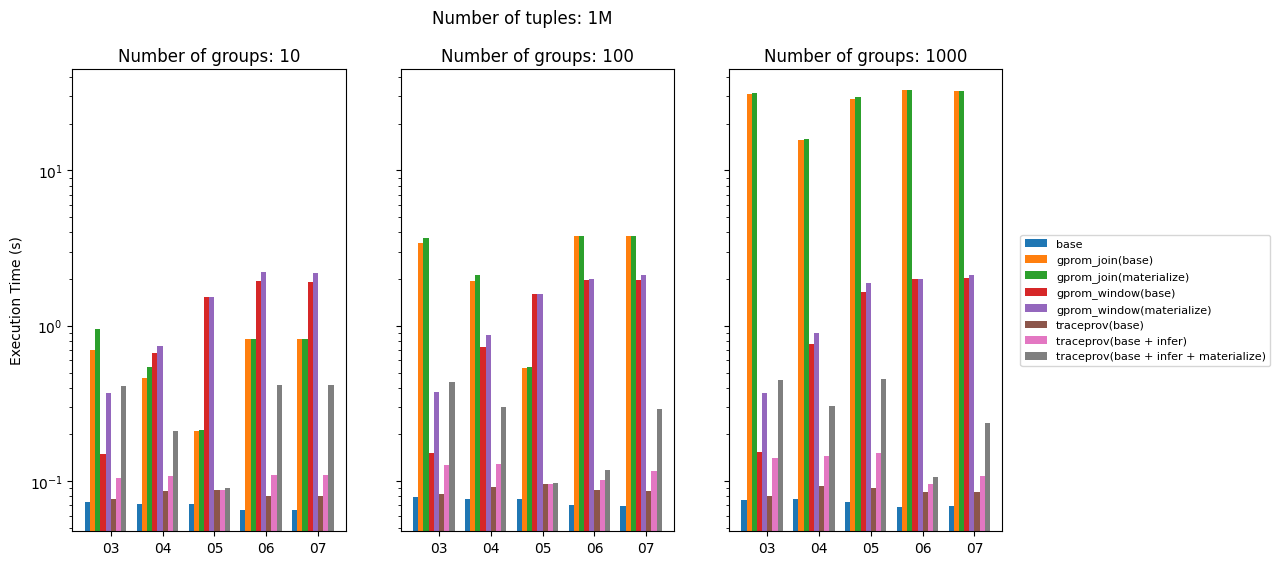

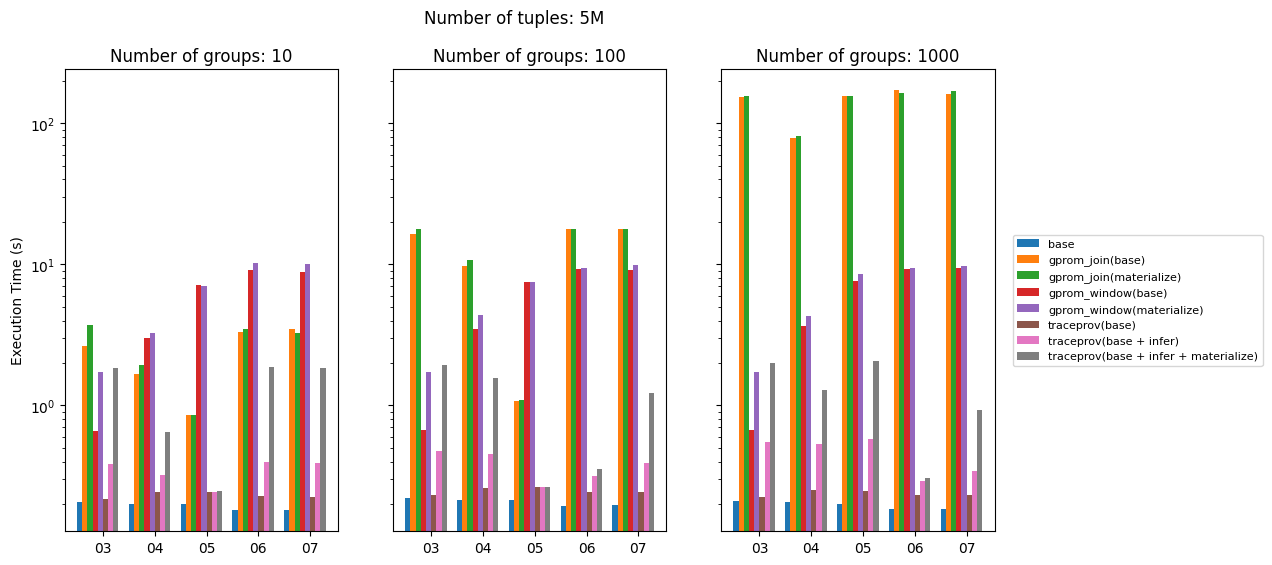

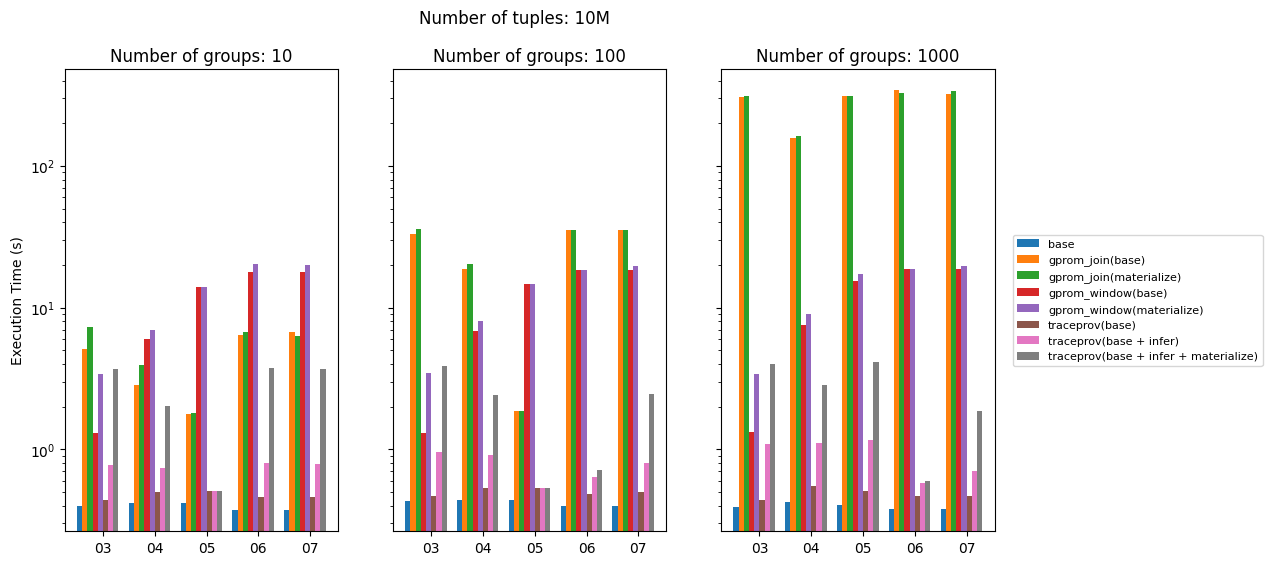

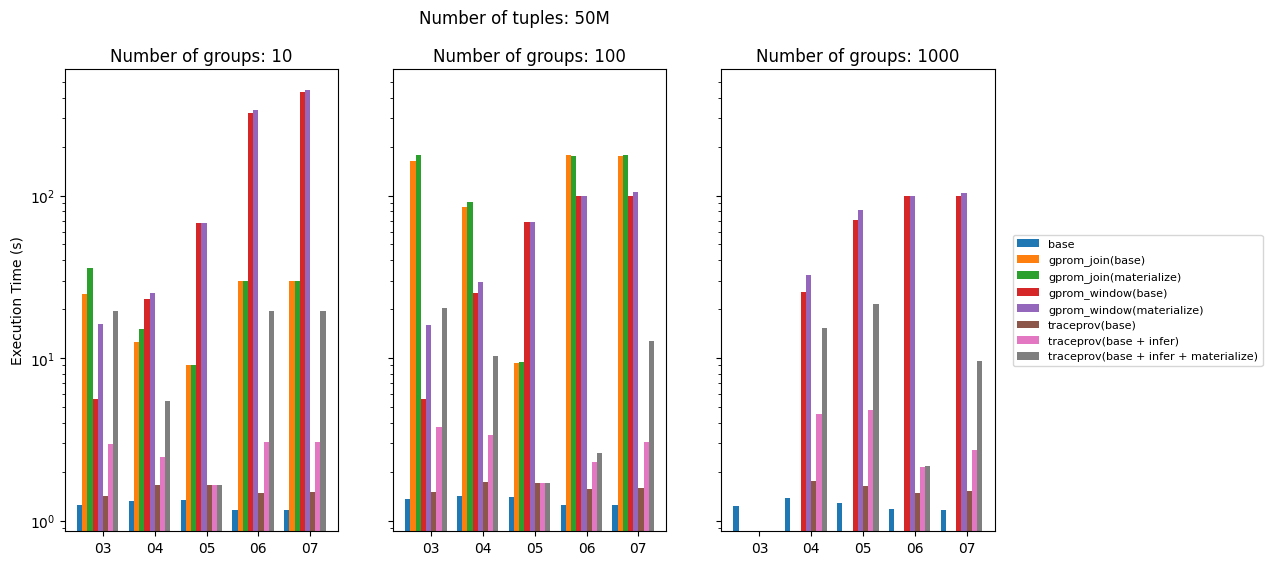

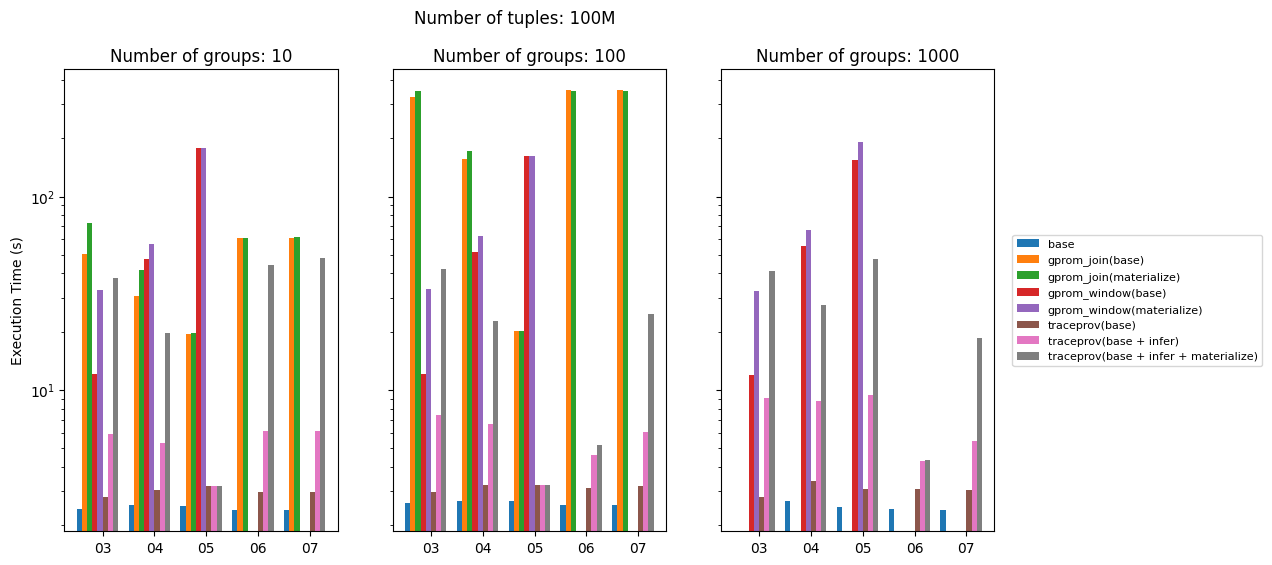

In [4]:
def plot_results_driver(results_dir='./'):
    num_tuples = [
        '1M', "5M", "10M", "50M", "100M"
    ]
    files = get_files_in_directory(results_dir)
    def _reduce(previous: dict, current: str):
        key = int('_'.join(current.split('_')[-2:-1]))
        return {**previous, key: [*previous.get(key, []), current]}
    grouped_per_db = reduce(_reduce, files, {})

    plt.clf()
    all_figures = []
    for i in range(5):
        figure, axs = plt.subplots(1, 3, sharey=True)
        figure.set_size_inches(12, 6)
        all_figures.append((figure, axs))
    
    all_results = []

    for _id, key in enumerate(sorted(grouped_per_db.keys())):
        print(key)
        plots = [axis[_id] for _, axis in all_figures]
        flat_results = plot_results(grouped_per_db[key], plots)
        for (_, axis) in all_figures:
            axis[_id].set_title(f"Number of groups: {key}")
        all_results.append((key, flat_results))
    
    for (fig, axis), num_tuple in zip(all_figures, num_tuples):
        axis[0].legend(loc='center right', prop=dict(size=8), bbox_to_anchor=(4.4, 0.5))
        fig.suptitle(f"Number of tuples: {num_tuple}")
        axis[0].set_ylabel("Execution Time (s)")
    plt.tight_layout()

    for (fig, _), num_tup in zip(all_figures, num_tuples):
        fig.savefig(f"{results_dir}/execution_time_{num_tup}.png", bbox_inches='tight')
    
    return all_results

all_results_combined = plot_results_driver('results_2025_09_25')

In [36]:
def flatten(combined_results):
    x = [(num_tup, (db, opaque_result)) for db, db_result in combined_results for num_tup, opaque_result in db_result]
    def _reduce(previous: dict, current):
        key, opaque_result = current
        return {
            **previous,
            key: [*previous.get(key, []), opaque_result]
        }
    grouped = reduce(_reduce, x, {})
    per_tup_result = {}
    all_headers = set()
    for num_tup, per_count_result in grouped.items():
        x = [(query, {f"[{db}] {impl}": query_result}) for (db, db_result) in per_count_result for (impl, impl_result) in db_result for (query, query_result) in impl_result ]
        per_tup_result[num_tup] = reduce(lambda previous, current: {**previous, current[0]: {**previous.get(current[0], {}), **current[1]}}, x, {})
        for _, query_pack in per_tup_result[num_tup].items():
            for header in query_pack:
                all_headers.add(header)
    all_headers_sorted = ['query', *list(sorted(list(all_headers)))]
    per_tup_augmented = {}
    for num_tup, query_results in per_tup_result.items():
        augmented_result = [{**dict(query=query), **{key: query_result[key] for key in all_headers}} for query, query_result in query_results.items()]
        augment_result_flat = [[str(sub_result[key]) for key in all_headers_sorted] for sub_result in augmented_result]
        per_tup_augmented[num_tup] = [ all_headers_sorted, *augment_result_flat]
    for num_tup, flattend in per_tup_augmented.items():
        file_str = '\n'.join(['\t'.join(row) for row in flattend])
        with open(f"{num_tup}.tsv", "w") as f:
            f.write(file_str)
        print(file_str)
    # print(all_headers_sorted)
    # print(per_tup_augmented)
flatten(all_results_combined)

query	[1000] base	[1000] gprom_join(base)	[1000] gprom_join(materialize)	[1000] gprom_window(base)	[1000] gprom_window(materialize)	[1000] traceprov(base + infer + materialize)	[1000] traceprov(base + infer)	[1000] traceprov(base)	[100] base	[100] gprom_join(base)	[100] gprom_join(materialize)	[100] gprom_window(base)	[100] gprom_window(materialize)	[100] traceprov(base + infer + materialize)	[100] traceprov(base + infer)	[100] traceprov(base)	[10] base	[10] gprom_join(base)	[10] gprom_join(materialize)	[10] gprom_window(base)	[10] gprom_window(materialize)	[10] traceprov(base + infer + materialize)	[10] traceprov(base + infer)	[10] traceprov(base)
03	0.0757795	31.06266	31.299961	0.15342100000000003	0.371486	0.4503425	0.1419755	0.0809755	0.0787925	3.4323975	3.703343	0.151825	0.37401399999999996	0.43291300000000005	0.1263415	0.08334150000000001	0.07302	0.6993754999999999	0.9514225000000001	0.14995999999999998	0.36945849999999997	0.4117535	0.1053635	0.0763635
04	0.07635399999999999	15.67